START OF PROJECT

In [17]:
import numpy as np
from pyscf import gto, dft, lo
from pyscf import ao2mo
from openfermion import FermionOperator
from pyscf.lib import unpack_tril
from openfermion import InteractionOperator, get_fermion_operator, jordan_wigner, count_qubits
from openfermion.chem import antisymtei
from qiskit.quantum_info import SparsePauliOp

xyz = """
C      0.0000     0.0000     0.0000
C      1.5290     0.0000     0.0000
O      2.0450     1.2070     0.0000
H     -0.5400     0.9000     0.0000
H     -0.5400    -0.9000     0.0000
H      1.9840    -0.5000    -0.8900
H      1.9840    -0.5000     0.8900
H      1.9840     0.8900     0.8900
H      2.9650     1.2070     0.0000
"""

xyz = """
C   0.000   0.000   0.000   # methyl carbon
C   0.000   0.000   1.460   # nitrile carbon
N   0.000   0.000   2.620   # nitrile nitrogen
H   1.020   0.000  -0.360   # methyl hydrogen
H  -0.510   0.883  -0.360
H  -0.510  -0.883  -0.360
"""

mol = gto.Mole()
mol.atom  = xyz
mol.basis = "def2-svp"
mol.build()

# ------------------------
# 2. Run DFT
# ------------------------
mf = dft.RKS(mol, xc="PBE0").run()
print("DEBUG: SCF converged energy:", mf.e_tot)

# ------------------------
# 3. Localize orbitals
# ------------------------
loc_coeff = lo.PM(mol).kernel(mf.mo_coeff)
print("DEBUG: loc_coeff shape:", loc_coeff.shape)

# ------------------------
# 4. Mulliken population analysis
# ------------------------
S = mol.intor("int1e_ovlp")
ao_labels = mol.ao_labels(fmt=False)
natm = mol.natm

ao_by_atom = [[] for _ in range(natm)]
for idx, (aidx, *_) in enumerate(ao_labels):
    ao_by_atom[aidx].append(idx)

occ = (mf.mo_occ > 0).astype(float) * 2

def per_orbital_mulliken(c_vec, occ_num=2.0):
    c_vec = np.asarray(c_vec).ravel()
    DSc = occ_num * (c_vec @ S) * c_vec
    return np.array([np.sum(DSc[idxs]) for idxs in ao_by_atom])

# ------------------------
# 5. Identify fragment orbitals
# ------------------------
FRAG_ATOMS = [2]
HIGH_THRSH = 0.30
LOW_THRSH  = 0.05

fragment_orbs, environment_orbs, undecided = [], [], []

for i in range(loc_coeff.shape[1]):
    pops = per_orbital_mulliken(loc_coeff[:, i], occ[i])
    occ_i = float(occ[i])
    frag_part = pops[FRAG_ATOMS].sum() / (occ_i if occ_i != 0.0 else 1.0)
    if frag_part > HIGH_THRSH:
        fragment_orbs.append(i)
    elif frag_part < LOW_THRSH:
        environment_orbs.append(i)
    else:
        undecided.append(i)

print("Fragment analysis")
print("--------------------------------")
print(f"Fragment atoms    : {FRAG_ATOMS}")
print(f"Fragment orbitals : {fragment_orbs}")
print(f"Environment orbs  : {environment_orbs}")
print(f"Undecided orbs    : {undecided}")

if len(fragment_orbs) == 0:
    raise ValueError("No fragment orbitals selected!")

# ------------------------
# 6. Fragment coefficient block
# ------------------------
C_frag = loc_coeff[:, fragment_orbs]

# Density matrix in localized MO basis

nmo = loc_coeff.shape[1]
D_ao = mf.make_rdm1()
D_mo = loc_coeff.T @ D_ao @ loc_coeff


frag_idx = np.array(fragment_orbs, dtype=int)
env_idx  = np.array(environment_orbs, dtype=int)

# Environment–fragment coupling block
D_EF = D_mo[np.ix_(env_idx, frag_idx)]

# SVD to obtain bath orbitals
U, svals, _ = np.linalg.svd(D_EF, full_matrices=False)

# Keep entangled bath orbitals
bath_mask = svals > 1e-8
nbath = np.sum(bath_mask)

if nbath == 0:
    raise ValueError("No bath orbitals found!")

bath_orbs = env_idx[:nbath]

print("Bath analysis")
print("--------------------------------")
print("Number of bath orbitals:", nbath)
print("Bath orbital indices:", bath_orbs.tolist())

# Embedded coefficient matrix (fragment + bath)
C_emb = np.hstack((loc_coeff[:, fragment_orbs],
                   loc_coeff[:, bath_orbs]))

n_emb = C_emb.shape[1]

# ------------------------
# 7. 1- and 2-electron integrals in embedded basis
# ------------------------
hcore_ao = mf.get_hcore().real
h1 = C_emb.T @ hcore_ao @ C_emb

eri_chemist = ao2mo.kernel(mol, C_emb, compact=False)
 
from pyscf import ao2mo
from pyscf import df

mf_df = mf.density_fit(auxbasis='weigend')
# AO → embedded MO 3-index integrals
Lpq = mf_df.with_df.ao2mo(C_emb)

eri_chemist = eri_chemist.reshape(n_emb, n_emb, n_emb, n_emb)
eri_phys = eri_chemist.transpose(0, 2, 1, 3)
eri_antisym = antisymtei(eri_phys)

print("DEBUG: Embedded h1 shape:", Lpq.shape)
print("DEBUG: Embedded ERI shape:", eri_antisym.shape)


H = FermionOperator()
print("Lpq shape:", Lpq.shape)
print("Expected packed size:", n_emb * (n_emb + 1) // 2)

# One-body
for p in range(n_emb):
    for q in range(n_emb):
        if abs(h1[p, q]) > 1e-12:
            H += FermionOperator(((p, 1), (q, 0)), h1[p, q])

# Two-body (Cholesky)

for L in range(Lpq.shape[0]):
    Lmat = unpack_tril(Lpq[L])

    for p in range(n_emb):
        for q in range(n_emb):
            v = Lmat[p, q]
            if abs(v) < 1e-12:
                continue

            op = FermionOperator(((p, 1), (q, 0)), v)
            H += 0.5 * op * op
# ------------------------
# 8. Build fermionic Hamiltonian
# ------------------------
quartic = [
    term for term in H.terms
    if len(term) == 4
]

print("Quartic terms:", len(quartic))

print("Number of Cholesky vectors:", Lpq.shape[0])


print("DEBUG: Fermionic operator term count:", len(H.terms))

jw_qubit_op = jordan_wigner(H)

num_qubits = count_qubits(jw_qubit_op)
print("DEBUG: Number of qubits:", num_qubits)

# ------------------------
# 9. Convert to SparsePauliOp
# ------------------------
def qubitop_to_sparsepauliop(qop, n_qubits):
    labels, coeffs = [], []
    for term, c in qop.terms.items():
        pauli_list = ['I'] * n_qubits
        for q, p in term:
            pauli_list[n_qubits - 1 - q] = p
        labels.append(''.join(pauli_list))
        coeffs.append(c)
    return SparsePauliOp.from_list(list(zip(labels, coeffs)))

sparse_op = qubitop_to_sparsepauliop(jw_qubit_op, num_qubits)

# ------------------------
# 10. Exact diagonalization
# ------------------------
H_mat = sparse_op.to_matrix()
evals = np.linalg.eigvalsh(H_mat)
exact_energy = evals[0]

print("DEBUG: Embedded exact ground-state energy (Ha):", exact_energy)


converged SCF energy = -132.491322453161
DEBUG: SCF converged energy: -132.4913224531606
DEBUG: loc_coeff shape: (57, 57)
Fragment analysis
--------------------------------
Fragment atoms    : [2]
Fragment orbitals : [0, 3, 8, 9, 10]
Environment orbs  : [1, 2, 4, 5, 6, 7, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56]
Undecided orbs    : []
Bath analysis
--------------------------------
Number of bath orbitals: 5
Bath orbital indices: [1, 2, 4, 5, 6]
DEBUG: Embedded h1 shape: (55, 55)
DEBUG: Embedded ERI shape: (10, 10, 10, 10)
Lpq shape: (55, 55)
Expected packed size: 55
Quartic terms: 96
Number of Cholesky vectors: 55
DEBUG: Fermionic operator term count: 196
DEBUG: Number of qubits: 10
DEBUG: Embedded exact ground-state energy (Ha): -102.61803077880181


In [18]:
from openfermion import InteractionOperator, get_fermion_operator, jordan_wigner
from openfermion.utils import count_qubits
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import TwoLocal, n_local, EfficientSU2
from qiskit.circuit.library import QAOAAnsatz

from scipy.sparse import csc_matrix
from scipy.sparse.linalg import eigsh



num_qubits = sparse_op.num_qubits
print("DEBUG: Creating ansatz for", num_qubits, "qubits")

ansatz = EfficientSU2(num_qubits, 
                      reps=3, 
                      entanglement='full', 
                      su2_gates=['ry','rz'])

print("DEBUG: Ansatz parameter count:", ansatz.num_parameters)

DEBUG: Creating ansatz for 10 qubits
DEBUG: Ansatz parameter count: 80


/tmp/ipykernel_2770/3726263000.py:15: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2(num_qubits,


In [20]:
from qiskit_ibm_runtime import QiskitRuntimeService
service = QiskitRuntimeService(channel='local')
backend = service.backend('aer_simulator')

from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

ansatz_isa = pm.run(ansatz)

hamiltonian_isa = sparse_op.apply_layout(layout=ansatz_isa.layout)

from qiskit.quantum_info import SparsePauliOp

H = hamiltonian_isa

# Force Hermiticity
H = 0.5 * (H + H.adjoint())

# Remove tiny numerical junk
H = H.simplify(atol=1e-10)

hamiltonian_isa = H

from qiskit.quantum_info import SparsePauliOp

num_params = ansatz_isa.num_parameters

def cost_func(params, ansatz, hamiltonian, estimator):
    """Return estimate of energy from estimator

    Parameters:
        params (ndarray): Array of ansatz parameters
        ansatz (QuantumCircuit): Parameterized ansatz circuit
        hamiltonian (SparsePauliOp): Operator representation of Hamiltonian
        estimator (EstimatorV2): Estimator primitive instance
        cost_history_dict: Dictionary for storing intermediate results

    Returns:
        float: Energy estimate
    """
    pub = (ansatz, [hamiltonian], [params])
    result = estimator.run(pubs=[pub]).result()
    energy = result[0].data.evs[0]

    cost_history_dict["iters"] += 1
    cost_history_dict["prev_vector"] = params
    cost_history_dict["cost_history"].append(energy)
    print(f"Iters. done: {cost_history_dict['iters']} [Current cost: {energy}]")
    
    cost = result[0].data.evs
    objective_func_vals.append(cost)
    return energy

cost_history_dict = {
    "prev_vector": None,
    "iters": 0,
    "cost_history": [],
}

x0 = 2 * np.pi * np.random.random(num_params)

from scipy.optimize import minimize
from qiskit_ibm_runtime import Session
from qiskit_ibm_runtime import EstimatorV2 as Estimator

cost_history_dict["iters"] = 0
objective_func_vals = [] # Global variable
with Session(backend=backend) as session:
    estimator = Estimator(mode=session)
    estimator.options.default_shots = 10000
    res = minimize(
        cost_func,
        x0,
        args=(ansatz_isa, hamiltonian_isa, estimator),
        method="cobyla",
    )

print("DEBUG: Initial parameters:", x0)

Iters. done: 1 [Current cost: -54.328812580969725]
Iters. done: 2 [Current cost: -53.86146057129391]
Iters. done: 3 [Current cost: -54.26614507484934]
Iters. done: 4 [Current cost: -53.84229656691963]
Iters. done: 5 [Current cost: -54.17556141318361]
Iters. done: 6 [Current cost: -54.11880111605558]
Iters. done: 7 [Current cost: -55.652777522652336]
Iters. done: 8 [Current cost: -54.31988255382669]
Iters. done: 9 [Current cost: -51.608685915115004]
Iters. done: 10 [Current cost: -51.68189032009089]
Iters. done: 11 [Current cost: -51.94229348496924]
Iters. done: 12 [Current cost: -55.42397336441528]
Iters. done: 13 [Current cost: -55.33048100241246]
Iters. done: 14 [Current cost: -55.57855702823972]
Iters. done: 15 [Current cost: -55.40935173820598]
Iters. done: 16 [Current cost: -55.723624053410695]
Iters. done: 17 [Current cost: -56.12400427695983]
Iters. done: 18 [Current cost: -56.24149944657816]
Iters. done: 19 [Current cost: -56.22961457968052]
Iters. done: 20 [Current cost: -56.2

KeyboardInterrupt: 

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService
service = QiskitRuntimeService(channel='local')
backend = service.backend('aer_simulator')

from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

ansatz_isa = pm.run(ansatz)

hamiltonian_isa = sparse_op.apply_layout(layout=ansatz_isa.layout)

from qiskit.quantum_info import SparsePauliOp

H = hamiltonian_isa

# Force Hermiticity
H = 0.5 * (H + H.adjoint())

# Remove tiny numerical junk
H = H.simplify(atol=1e-10)

hamiltonian_isa = H

num_params = ansatz_isa.num_parameters

# # ------------------------
# # Dynamic shot parameters
# # ------------------------
# MIN_SHOTS = 1_000
# MAX_SHOTS = 20_000
# SHOT_GROWTH = 0.05  # growth rate per iteration



MIN_SHOTS = 1_000
MAX_SHOTS = 20_000

WINDOW = 10           # rolling window size
EPS = 1e-8            # numerical safety


def variance_based_shots(cost_history):
    if len(cost_history) < WINDOW:
        return MIN_SHOTS

    recent = np.array(cost_history[-WINDOW:])
    var = np.var(recent)

    # Reference variance = variance at first stable window
    if "ref_var" not in cost_history_dict:
        cost_history_dict["ref_var"] = max(var, EPS)

    shots = MIN_SHOTS * (cost_history_dict["ref_var"] / max(var, EPS))
    return int(np.clip(shots, MIN_SHOTS, MAX_SHOTS))



def cost_func(params, ansatz, hamiltonian, estimator):
    """Return estimate of energy from estimator with dynamic shots"""

    # --- dynamic shot allocation ---
    k = cost_history_dict["iters"]
    # shots = int(min(MAX_SHOTS, MIN_SHOTS * (1 + SHOT_GROWTH * k)))
    # estimator.options.default_shots = shots

    shots = variance_based_shots(cost_history_dict["cost_history"])
    estimator.options.default_shots = shots

    pub = (ansatz, [hamiltonian], [params])
    result = estimator.run(pubs=[pub]).result()
    energy = result[0].data.evs[0]

    cost_history_dict["iters"] += 1
    cost_history_dict["prev_vector"] = params
    cost_history_dict["cost_history"].append(energy)

    print(
        f"Iters. done: {cost_history_dict['iters']} "
        f"[Shots: {shots}, Current cost: {energy}]"
    )

    objective_func_vals.append(result[0].data.evs)
    return energy


cost_history_dict = {
    "prev_vector": None,
    "iters": 0,
    "cost_history": [],
}

x0 = 2 * np.pi * np.random.random(num_params)

from scipy.optimize import minimize
from qiskit_ibm_runtime import Session
from qiskit_ibm_runtime import EstimatorV2 as Estimator

objective_func_vals = []

with Session(backend=backend) as session:
    estimator = Estimator(mode=session)
    estimator.options.default_shots = MIN_SHOTS

    res = minimize(
        cost_func,
        x0,
        args=(ansatz_isa, hamiltonian_isa, estimator),
        method="cobyla",
    )

print("DEBUG: Initial parameters:", x0)


Iters. done: 1 [Shots: 1000, Current cost: -53.66352279683231]
Iters. done: 2 [Shots: 1000, Current cost: -52.46057723691579]
Iters. done: 3 [Shots: 1000, Current cost: -51.66809514557112]
Iters. done: 4 [Shots: 1000, Current cost: -53.134577990633225]
Iters. done: 5 [Shots: 1000, Current cost: -53.27910332669842]
Iters. done: 6 [Shots: 1000, Current cost: -52.56208183098182]
Iters. done: 7 [Shots: 1000, Current cost: -51.733735214933894]
Iters. done: 8 [Shots: 1000, Current cost: -54.66943876643239]
Iters. done: 9 [Shots: 1000, Current cost: -56.0534909662667]
Iters. done: 10 [Shots: 1000, Current cost: -54.12391658650218]
Iters. done: 11 [Shots: 1000, Current cost: -57.892480868011056]
Iters. done: 12 [Shots: 1000, Current cost: -58.100288240919916]
Iters. done: 13 [Shots: 1000, Current cost: -57.79298280275059]
Iters. done: 14 [Shots: 1000, Current cost: -57.97838984443557]
Iters. done: 15 [Shots: 1000, Current cost: -57.316290891625066]
Iters. done: 16 [Shots: 1000, Current cost: -

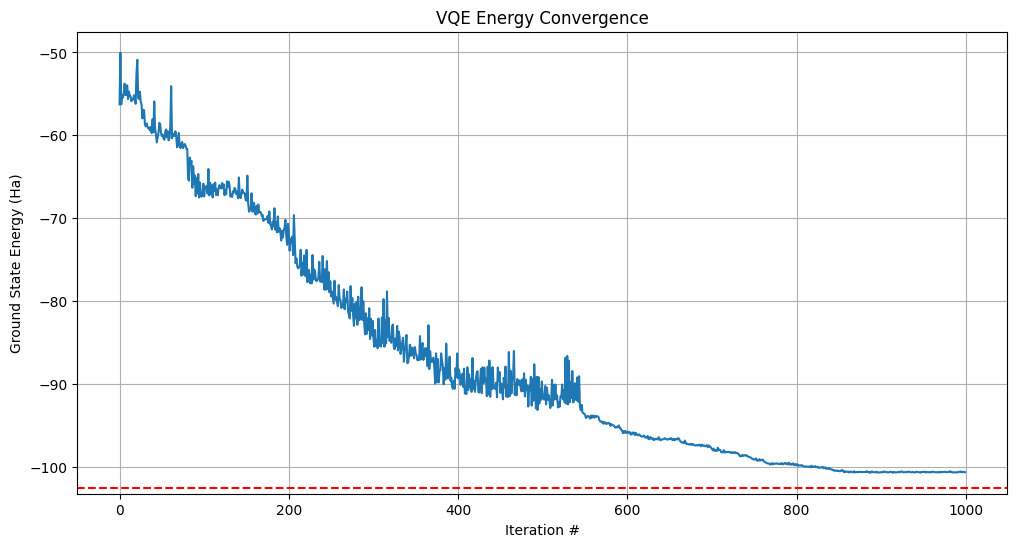

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(cost_history_dict["cost_history"])
plt.xlabel("Iteration #")
plt.ylabel("Ground State Energy (Ha)")
plt.axhline(y=exact_energy, color='r', linestyle='--', label="Exact Fragment Energy")
plt.title("VQE Energy Convergence")
plt.grid(True)
plt.show()

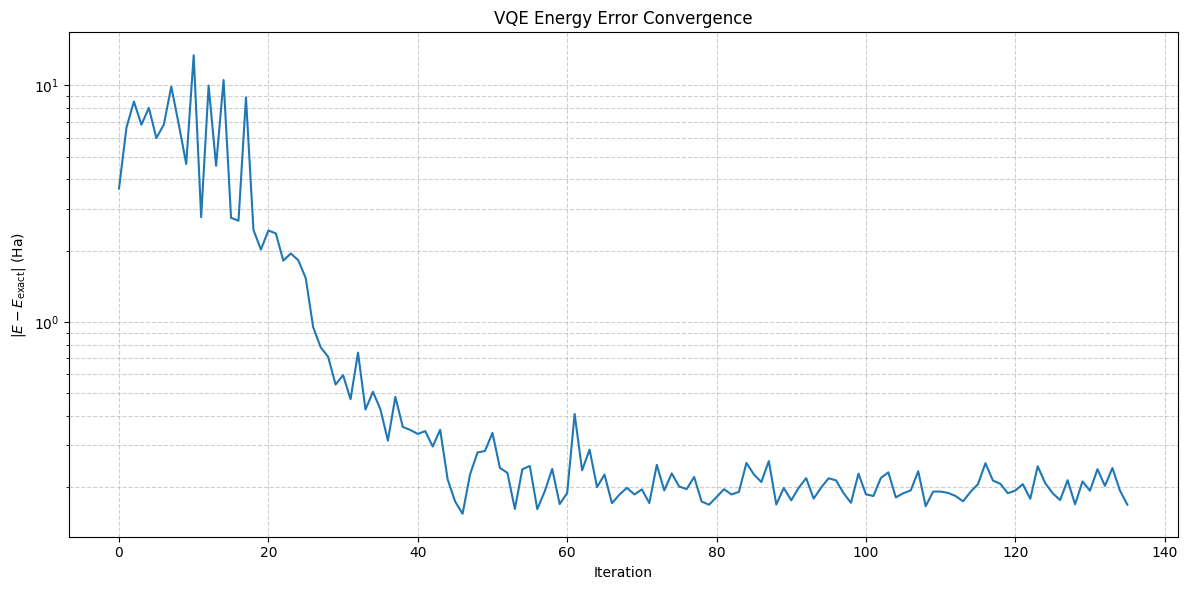

In [15]:
import numpy as np
import matplotlib.pyplot as plt

energies = np.array(cost_history_dict["cost_history"])
errors = np.abs(energies - exact_energy)

plt.figure(figsize=(12, 6))
plt.semilogy(errors)
plt.xlabel("Iteration")
plt.ylabel(r"$|E - E_{\mathrm{exact}}|$ (Ha)")
plt.title("VQE Energy Error Convergence")
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [16]:
print(min(objective_func_vals))

approx_energy = min(objective_func_vals)[0]
percent_error = abs(approx_energy - exact_energy) / abs(exact_energy) * 100
print(f"Percent Error: {percent_error:.4f}%")


[-38.08077041]
Percent Error: 0.4028%
